<a href="https://colab.research.google.com/github/Steph-The-Dev/2026_GSERM_DL/blob/main/2026_GSERM_DL_Stephan_Pfeiffer_exam_exercise_agy_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" style="max-width: 200px; height: auto" src="https://github.com/Steph-The-Dev/2026_GSERM_DL/blob/main/hsg_logo.png?raw=1">

##  Assignment - Fashion MNIST Convolutional Neural Networks (CNNs)

GSERM'26 course "Deep Learning: Fundamentals and Applications", University of St. Gallen

This week we have learned how to enhance vanilla Artificial Neural Networks (ANNs) using `PyTorch` to classify even more complex images. For this purpose, we used a special type of deep neural network referred to **Convolutional Neural Networks (CNNs)**. In our exam exercise, we aim to leverage that knowledge by applying it to the known Fashion-MNIST dataset.

As always, pls. don't hesitate to post your potential questions on CANVAS (StudyNet) forum (https://learning.unisg.ch), or send us an email (using the course email: aiml-teaching.ics@unisg.ch).

## 1. Assignment Objectives:

As discussed in our last session, these are the tasks for the exam exercise:

> 1. Load the Fashion **MNIST dataset**.
> 2. Implement a **CNN** architecture able to work with this data.
> 3. **Train** the model, evaluate its **performance** and visualize the results.
> 4. Try to **improve** the performance of the initial model.
> 5. **Document** the results in the form of PowerPoint slides.

## 2. Setup of the Jupyter Notebook Environment

Similar to the previous labs, we need to import a couple of Python libraries that allow for data analysis and data visualization. We will mostly use the `PyTorch`, `Numpy`, `Sklearn`, `Matplotlib`, `Seaborn` and a few utility libraries throughout this lab:

In [1]:
# import standard python libraries
import os, urllib, io
from datetime import datetime
import numpy as np


Import Python machine / deep learning libraries:

In [2]:
# import the PyTorch deep learning library
import torch, torchvision
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable


Import the sklearn classification metrics:

In [3]:
# import sklearn classification evaluation library
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix


Import Python plotting libraries:

In [4]:
# import matplotlib, seaborn, and PIL data visualization libary
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


Enable notebook matplotlib inline plotting:

In [5]:
%matplotlib inline


Import Google's GDrive connector and mount your GDrive directories:

In [6]:
# import the Google Colab GDrive connector
try:
    from google.colab import drive
    # mount GDrive inside the Colab notebook
    drive.mount('/content/drive')
    IN_COLAB = True
    print("[LOG] Running in Google Colab. GDrive mounted.")
except ImportError:
    IN_COLAB = False
    print("[LOG] Running locally - Google Colab GDrive mount skipped.")

Mounted at /content/drive
[LOG] Running in Google Colab. GDrive mounted.


Create a structure of Colab Notebook sub-directories inside of GDrive to store (1) the data as well as (2) the trained neural network models:

In [7]:
# create directories dynamically depending on running environment
base_dir = '/content/drive/MyDrive/Colab Notebooks/2026_GSERM_DL-Stephan_Pfeiffer-assignment' if IN_COLAB else '.'
data_directory = os.path.join(base_dir, 'data')
models_directory = os.path.join(base_dir, 'models')

# Create necessary directories
for directory in [data_directory, models_directory]:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"[LOG] Created directory: {directory}")

Set a random `seed` value to obtain reproducable results:

In [8]:
# init deterministic seed
seed_value = 4242
np.random.seed(seed_value) # set numpy seed
torch.manual_seed(seed_value) # set pytorch seed CPU


In [9]:
import random

def make_deterministic(seed):
    # 1. Basic Python and Numpy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. PyTorch CPU and GPU seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if using multi-GPU

    # 3. Force CuDNN to be deterministic
    # Note: This might make training slightly slower
    # [SUGGESTION]: Setting deterministic=True can significantly slow down CNN training
    # because it prevents CuDNN from finding the fastest convolution algorithms.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 4. Optional: Force PyTorch to use deterministic algorithms where available
    # torch.use_deterministic_algorithms(True)

    print(f"[LOG] Deterministic environment set with seed: {seed}")

# Apply the strict seeding
make_deterministic(seed_value)

[LOG] Deterministic environment set with seed: 4242


Google Colab provides the use of free GPUs for running notebooks. However, if you just execute this notebook as is, it will use your device's CPU. To run the lab on a GPU, got to `Runtime` > `Change runtime type` and set the Runtime type to `GPU` in the drop-down. Running this lab on a CPU is fine, but you will find that GPU computing is faster. *CUDA* indicates that the lab is being run on GPU.

Enable GPU computing by setting the `device` flag and init a `CUDA` seed:

In [10]:
# set cpu or gpu enabled device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# init deterministic GPU seed if GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

# log type of device enabled
print(f'[LOG] notebook with {device} computation enabled')

[LOG] notebook with cuda computation enabled


Let's determine if we have access to a GPU provided by e.g. Google's COLab environment:

In [11]:
# Check GPU details if available
if torch.cuda.is_available():
    import subprocess
    print(subprocess.check_output("nvidia-smi").decode("utf-8"))
else:
    print("[LOG] CUDA GPU is not available. Skipping nvidia-smi check.")

Sat Jun 27 15:36:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Exam Exercise: Convolutional Neural Networks (CNNs)

The **Fashion-MNIST database** is a large database of Zalando articles that is commonly used for training various image processing systems. The database is widely used for training and testing in the field of machine learning. Source: https://www.kaggle.com/c/insar-fashion-mnist-challenge

### 3.1 Fashion-MNIST Dataset Download and Data Assessment

[LOG] Train dataset size: 50000
[LOG] Validation dataset size: 10000
[LOG] Eval (Test) dataset size:  10000


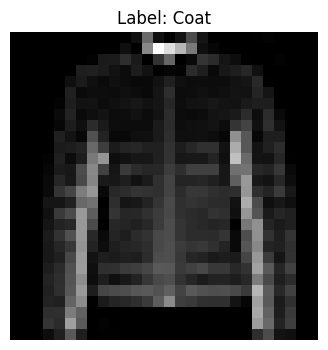

In [12]:
# Setup train/eval paths and download datasets using portable paths
train_path = os.path.join(data_directory, 'train_fmnist')
eval_path = os.path.join(data_directory, 'eval_fmnist')

# Define PyTorch transformation into tensor format
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

# Download and transform training and evaluation datasets
full_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=transf, download=True)
fashion_mnist_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=transf, download=True)

# [SUGGESTION]: Split the full training data into training (50k) and validation (10k) sets
from torch.utils.data import random_split
train_size = 50000
val_size = len(full_train_data) - train_size
fashion_mnist_train_data, fashion_mnist_val_data = random_split(full_train_data, [train_size, val_size])

print(f"[LOG] Train dataset size: {len(fashion_mnist_train_data)}")
print(f"[LOG] Validation dataset size: {len(fashion_mnist_val_data)}")
print(f"[LOG] Eval (Test) dataset size:  {len(fashion_mnist_eval_data)}")

# Setup class label mapping
fashion_classes = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# Inspect a random sample image
image_id = 42424
fashion_mnist_train_image, fashion_mnist_train_label = fashion_mnist_train_data[0]

# Convert tensor to PIL image for visualization
trans = torchvision.transforms.ToPILImage()
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.title(f'Label: {fashion_classes[fashion_mnist_train_label]}')
plt.imshow(trans(fashion_mnist_train_image), cmap='gray')
plt.axis('off')
plt.show()


### 3.2 Convolutional Neural Network (CNN) Model Training and Evaluation

In [13]:
# [SUGGESTION]: Reusable training function to avoid code duplication (DRY principle)
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, models_directory, model_name_prefix, scheduler=None, device='cpu'):
    # Note: torch, np, os, and datetime are used from global scope (imported in earlier cells)
    train_losses = []
    val_losses = []

    print(f"[LOG] Starting training for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        batch_losses = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        epoch_train_loss = np.mean(batch_losses)
        train_losses.append(epoch_train_loss)

        # --- VALIDATION PHASE ---
        if val_loader is not None:
            model.eval()
            val_batch_losses = []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    output = model(images)
                    loss = criterion(output, labels)
                    val_batch_losses.append(loss.item())

            epoch_val_loss = np.mean(val_batch_losses)
            val_losses.append(epoch_val_loss)

            if scheduler is not None:
                scheduler.step(epoch_val_loss)
        else:
            epoch_val_loss = 0.0
            if scheduler is not None:
                scheduler.step()

        # Save checkpoint
        model_name = f'{model_name_prefix}_epoch_{epoch}.pth'
        torch.save(model.state_dict(), os.path.join(models_directory, model_name))

        # Logging
        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs - 1:
            now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            current_lr = optimizer.param_groups[0]['lr']
            log_str = f'[LOG {now}] Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {epoch_train_loss:.4f}'
            if val_loader is not None:
                log_str += f' | Val Loss: {epoch_val_loss:.4f}'
            if scheduler is not None:
                log_str += f' | LR: {current_lr:.6f}'
            print(log_str)

    return train_losses, val_losses


In [14]:
# Define Validation Dataloader globally for reuse
fmnist_val_dataloader = torch.utils.data.DataLoader(
    fashion_mnist_val_data,
    batch_size=128,
    shuffle=False,
    num_workers=1,        # Safe default for Windows
    pin_memory=True
)


**3.2.1. Implement and train your "baseline" CNN.**

In [15]:
# Implement the baseline FMNISTNet architecture (modified LeNet-5)
class FMNISTNet(nn.Module):
    def __init__(self):
        super(FMNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.linear1 = nn.Linear(16 * 4 * 4, 120, bias=True)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(120, 84, bias=True)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(84, 10)
        # [SUGGESTION]: Removed LogSoftmax, returning raw logits for CrossEntropyLoss

    def forward(self, images):
        x = self.pool1(self.relu1(self.conv1(images)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = self.relu1(self.linear1(x))
        x = self.relu2(self.linear2(x))
        x = self.linear3(x)
        return x

model = FMNISTNet().to(device)
print(f'[LOG] FMNISTNet architecture:\n\n{model}\n')

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[LOG] Number of trainable parameters: {num_params}')

# [SUGGESTION]: Use CrossEntropyLoss which combines LogSoftmax and NLLLoss
criterion = nn.CrossEntropyLoss().to(device)
learning_rate = 0.001
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)

num_epochs = 30
mini_batch_size = 128
fmnist_train_dataloader = torch.utils.data.DataLoader(
    fashion_mnist_train_data,
    batch_size=mini_batch_size,
    shuffle=True,
    num_workers=1,        # Safe default for Windows
    pin_memory=True
)

# [SUGGESTION]: Replace verbose loop with train_model function call
train_epoch_losses, val_epoch_losses = train_model(
    model=model,
    train_loader=fmnist_train_dataloader,
    val_loader=fmnist_val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs,
    models_directory=models_directory,
    model_name_prefix='fmnist_model',
    device=device
)


[LOG] FMNISTNet architecture:

FMNISTNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=256, out_features=120, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=120, out_features=84, bias=True)
  (relu2): ReLU()
  (linear3): Linear(in_features=84, out_features=10, bias=True)
)

[LOG] Number of trainable parameters: 44426
[LOG] Starting training for 30 epochs...
[LOG 2026-06-27 15:36:39] Epoch 01/30 | Train Loss: 2.3044 | Val Loss: 2.3026
[LOG 2026-06-27 15:37:19] Epoch 05/30 | Train Loss: 2.2827 | Val Loss: 2.2797
[LOG 2026-06-27 15:38:09] Epoch 10/30 | Train Loss: 2.1823 | Val Loss: 2.1530
[LOG 2026-06-27 15:38:59] Epoch 15/30 | Train Loss: 1.1378 | Val Loss: 1.0808
[LOG 2026-06-27 15:39:48] Epoch 20/3

Visualizing training errors

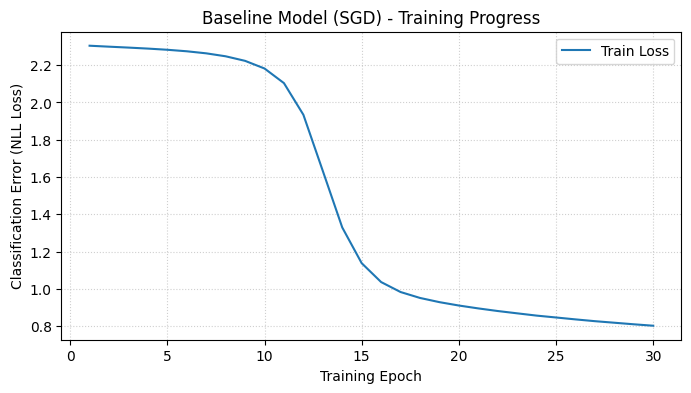

[LOG] Successfully loaded baseline checkpoint.
[RESULT] Baseline Overall Accuracy: 69.67%


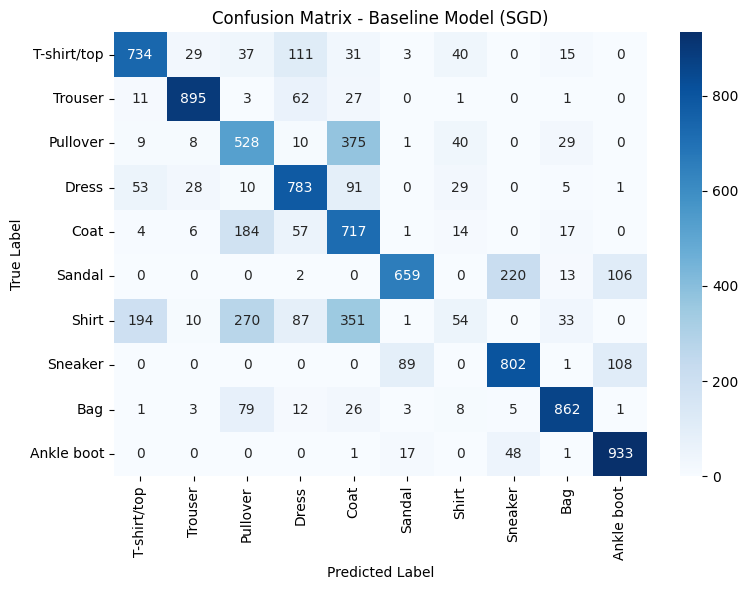

In [16]:
# Plot training progress curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_epoch_losses) + 1), train_epoch_losses, label='Train Loss', color='#1f77b4')
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Classification Error (NLL Loss)", fontsize=10)
plt.title("Baseline Model (SGD) - Training Progress", fontsize=12)
plt.legend()
plt.show()

# Load model weights from checkpoint with fallback to in-memory model state
best_model_name = os.path.join(models_directory, 'fmnist_model_epoch_29.pth')
best_model = FMNISTNet().to(device)
if os.path.exists(best_model_name):
    best_model.load_state_dict(torch.load(best_model_name, map_location=device))
    print("[LOG] Successfully loaded baseline checkpoint.")
else:
    best_model.load_state_dict(model.state_dict())
    print("[WARNING] Baseline checkpoint not found. Used final in-memory state.")
best_model.eval()

# Consistent evaluation using mini-batches via DataLoader to prevent memory issues
eval_dataloader = torch.utils.data.DataLoader(fashion_mnist_eval_data, batch_size=128, shuffle=False)
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in eval_dataloader:
        images = images.to(device)
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

acc_baseline = metrics.accuracy_score(all_targets, all_preds)
print(f'[RESULT] Baseline Overall Accuracy: {acc_baseline * 100:.2f}%')

# Visualise confusion matrix
mat = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Baseline Model (SGD)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**3.2.2. Implement and train your "improved" CNN.**
("improved" simply refers to a better classification accuracy than your baseline model)

In this section, we implement an improved version using the **Adam Optimizer** and a slightly deeper architecture with **Dropout**.

In [17]:
# Implement an Improved CNN with more channels, dropout, and batch normalization
class ImprovedFMNISTNet(nn.Module):
    def __init__(self):
        super(ImprovedFMNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        import torch.nn.functional as F
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        # [SUGGESTION]: Returning raw logits instead of F.log_softmax for CrossEntropyLoss
        return x

improved_model = ImprovedFMNISTNet().to(device)
print(f'[LOG] ImprovedFMNISTNet architecture:\n\n{improved_model}\n')

num_params_improved = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)
print(f'[LOG] Number of trainable parameters (Improved Model): {num_params_improved}')

optimizer = optim.Adam(improved_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss().to(device)
num_epochs_improved = 30

# [SUGGESTION]: Call train_model function
train_losses_improved, val_losses_improved = train_model(
    model=improved_model,
    train_loader=fmnist_train_dataloader,
    val_loader=fmnist_val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs_improved,
    models_directory=models_directory,
    model_name_prefix='fmnist_improved',
    device=device
)



[LOG] ImprovedFMNISTNet architecture:

ImprovedFMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

[LOG] Number of trainable parameters (Improved Model): 207018
[LOG] Starting training for 30 epochs...
[LOG 2026-06-27 15:41:40] Epoch 01/30 | Train Loss: 0.5040 | Val Loss: 0.3230
[LOG 2026-06-27 15:42:20] Epoch 05/30 | Train Loss: 0.2672 | Val Loss: 0.2478
[LOG 2026-06-27 15:43:10] Epoch 10/30 | Train Loss: 0.2116 | Val Loss: 0.2291
[LOG 2026-06-27 15

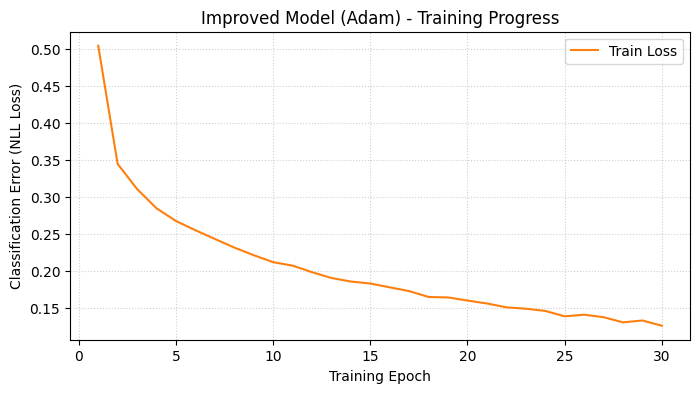

[LOG] Successfully loaded improved checkpoint.
[RESULT] Improved Overall Accuracy: 91.14%


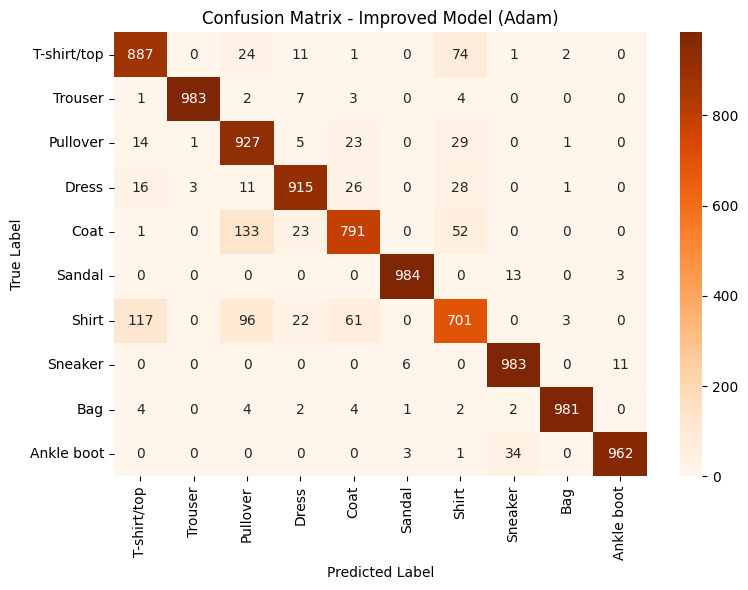

In [18]:
# Plot training progress curve for Improved Model
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses_improved) + 1), train_losses_improved, label='Train Loss', color='#ff7f0e')
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Classification Error (NLL Loss)", fontsize=10)
plt.title("Improved Model (Adam) - Training Progress", fontsize=12)
plt.legend()
plt.show()

# Load checkpoint with fallback
improved_model_path = os.path.join(models_directory, 'fmnist_improved_epoch_29.pth')
best_improved_model = ImprovedFMNISTNet().to(device)
if os.path.exists(improved_model_path):
    best_improved_model.load_state_dict(torch.load(improved_model_path, map_location=device))
    print("[LOG] Successfully loaded improved checkpoint.")
else:
    best_improved_model.load_state_dict(improved_model.state_dict())
    print("[WARNING] Improved checkpoint not found. Used final in-memory state.")
best_improved_model.eval()

# Run evaluation on test dataset using DataLoader
all_preds_improved = []
all_targets_improved = []
with torch.no_grad():
    for images, labels in eval_dataloader:
        images = images.to(device)
        outputs = best_improved_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds_improved.extend(preds.cpu().numpy())
        all_targets_improved.extend(labels.numpy())

acc_improved = metrics.accuracy_score(all_targets_improved, all_preds_improved)
print(f'[RESULT] Improved Overall Accuracy: {acc_improved * 100:.2f}%')

# Visualise confusion matrix for the improved model
mat_improved = confusion_matrix(all_targets_improved, all_preds_improved)
plt.figure(figsize=(8, 6))
sns.heatmap(mat_improved, annot=True, fmt='d', cmap='Oranges',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Improved Model (Adam)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 4. Comparison: Baseline (SGD) vs. Improved (Adam)
In this final step, we compare the learning speed and the final accuracy of both approaches to demonstrate the effectiveness of the architectural and optimization changes.

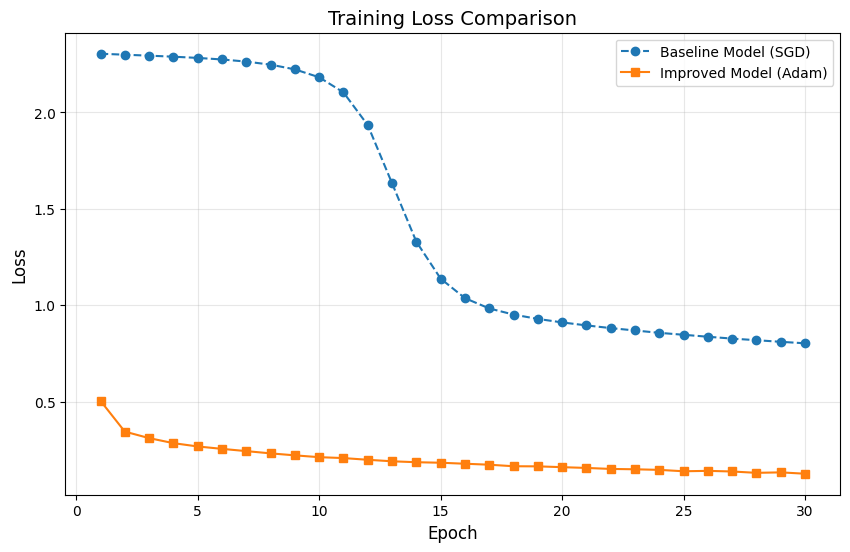

,Model,Optimizer,Epochs,Final Training Loss,Evaluation Accuracy
0,Baseline (SGD),SGD,30,0.8023,69.67%
1,Improved (Adam),Adam,30,0.1258,91.14%


In [19]:
# 1. Plot comparison of training losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_epoch_losses) + 1), train_epoch_losses, label='Baseline Model (SGD)', marker='o', color='#1f77b4', linestyle='--')
plt.plot(range(1, len(train_losses_improved) + 1), train_losses_improved, label='Improved Model (Adam)', marker='s', color='#ff7f0e')

plt.title('Training Loss Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Create a summary table for baseline and improved models
data = {
    'Model': ['Baseline (SGD)', 'Improved (Adam)'],
    'Optimizer': ['SGD', 'Adam'],
    'Epochs': [num_epochs, num_epochs_improved],
    'Final Training Loss': [f"{train_epoch_losses[-1]:.4f}", f"{train_losses_improved[-1]:.4f}"],
    'Evaluation Accuracy': [f"{acc_baseline*100:.2f}%", f"{acc_improved*100:.2f}%"]
}

import pandas as pd
comparison_df = pd.DataFrame(data)
display(comparison_df)

In [20]:
# Calculate complexity difference
print(f'[LOG] Parameters Baseline Model:  {num_params}')
print(f'[LOG] Parameters Improved Model:  {num_params_improved}')
print(f'[LOG] Complexity Increase:       {((num_params_improved/num_params)-1)*100:.2f}%')

[LOG] Parameters Baseline Model:  44426
[LOG] Parameters Improved Model:  207018
[LOG] Complexity Increase:       365.98%


## 5. Model Complexity Analysis

Although the improved model is significantly more powerful, the number of parameters (approx. 200k) is still low compared to modern deep learning architectures, but considerably higher than the baseline model (~44k).

**Key Differences:**

1. **Filter Depth (Convolutional Layers):**

* **Baseline:** 6 filters in the first layer, 16 in the second layer.

* **Improved:** 16 filters in the first layer, 32 in the second layer. This allows the model to recognize significantly more complex visual patterns (such as textures or specific collar shapes on shirts).

2. **Regularization through Dropout:**

* The improved model uses **Dropout (0.25)**. While this does not increase the number of parameters, it does increase the *effective complexity* during training. It forces the network to learn redundant paths and prevents it from relying on single, overly specific features (overfitting).


3. **Fully Connected Layer:**

* Due to the increased number of filters at the end of the convolutional layers, the input for the first dense layer (`fc1`) also increases. The improved model has a larger matrix here, which increases its capacity to correctly classify the extracted features.

4. **Optimizer (Adam vs. SGD):**

* This is not a difference in structural complexity, but a functional one: Adam uses a separate, adaptive learning rate for each parameter. This makes the computational effort per step slightly higher, but leads to much more efficient navigation through the high-dimensional parameter space.

## 6. Strategies for Further Improvements

To further enhance the performance of CNNs on Fashion-MNIST, the following advanced techniques can be employed:

1. **Data Augmentation:** By randomly flipping the image horizontally (`RandomHorizontalFlip`) or performing slight rotations, the model learns more general features and becomes more robust against variations in image position.

2. **Batch Normalization:** Adding `nn.BatchNorm2d` layers after the convolutional layers significantly stabilizes the learning process and often allows for even higher learning rates.

3. **Learning Rate Scheduling:** Instead of a fixed learning rate, it can be reduced during training (e.g., using `StepLR`) if the loss plateaus. This helps the model to "fine-tune" to the global minimum of the loss function.

4. **Transfer Learning:** One could use pre-trained architectures (like ResNet), but this is often overkill for the low resolution of 28x28 pixels.

## 7. Data Augmentation and Refined Normalization with Dataset Statistics
Instead of generic values, we use the specific global mean and standard deviation of Fashion-MNIST to standardize our input data.

In [21]:
# Exact global mean and standard deviation of the Fashion-MNIST dataset
fmnist_mean = (0.2860,)
fmnist_std = (0.3530,)

# Transformation pipelines using exact stats
train_transf_final = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomRotation(degrees=10),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(fmnist_mean, fmnist_std)
])

eval_transf_final = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(fmnist_mean, fmnist_std)
])

print(f"[LOG] Refined Normalization parameters updated: Mean {fmnist_mean}, Std {fmnist_std}")

[LOG] Refined Normalization parameters updated: Mean (0.286,), Std (0.353,)


### 7.1 Training with Data Augmentation & Normalization

We now apply the `final` transformations, create new DataLoaders, and train a model to observe the effect of data augmentation.

In [22]:
# Load augmented training data and normalized evaluation data
augmented_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=train_transf_final, download=True)
final_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=eval_transf_final, download=True)

# Create Dataloaders
augmented_train_dataloader = torch.utils.data.DataLoader(augmented_train_data, batch_size=mini_batch_size, shuffle=True, num_workers=1, pin_memory=True)
final_eval_dataloader = torch.utils.data.DataLoader(final_eval_data, batch_size=mini_batch_size, shuffle=False, num_workers=1, pin_memory=True)

# Initialize final model (using ImprovedFMNISTNet architecture)
final_model = ImprovedFMNISTNet().to(device)
optimizer = optim.Adam(final_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss().to(device)

num_epochs_final = 30

# [SUGGESTION]: Replace verbose loop with train_model function call
train_losses_final, _ = train_model(
    model=final_model,
    train_loader=augmented_train_dataloader,
    val_loader=None,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs_final,
    models_directory=models_directory,
    model_name_prefix='fmnist_final',
    device=device
)

# Evaluate final model accuracy
final_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in final_eval_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        preds = torch.argmax(outputs.data, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

acc_final = correct / total
print(f'\n[RESULT] Final Model Accuracy (Augmentation + Exact Stats): {acc_final * 100:.2f}%')


[LOG] Starting training for 30 epochs...
[LOG 2026-06-27 15:46:57] Epoch 01/30 | Train Loss: 0.5453
[LOG 2026-06-27 15:48:40] Epoch 05/30 | Train Loss: 0.3211
[LOG 2026-06-27 15:50:42] Epoch 10/30 | Train Loss: 0.2812
[LOG 2026-06-27 15:52:44] Epoch 15/30 | Train Loss: 0.2559
[LOG 2026-06-27 15:54:49] Epoch 20/30 | Train Loss: 0.2384
[LOG 2026-06-27 15:56:53] Epoch 25/30 | Train Loss: 0.2300
[LOG 2026-06-27 15:58:57] Epoch 30/30 | Train Loss: 0.2220

[RESULT] Final Model Accuracy (Augmentation + Exact Stats): 91.80%


### 7.1.2 Visualization of the Data Augmentation & Normalization Model Results
Here we analyze the confusion matrix for the version with data augmentation and exact statistics.

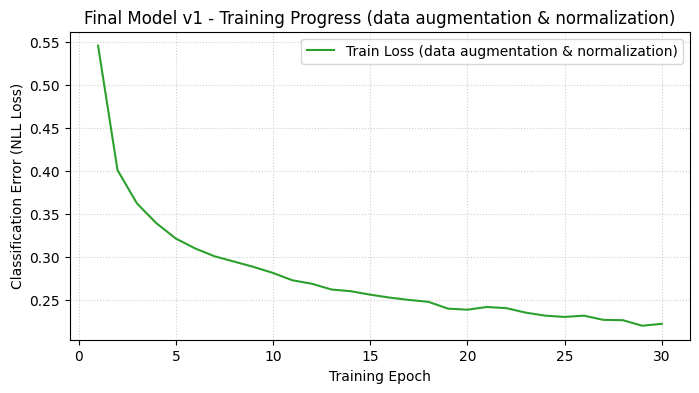

In [23]:
# Plot training progress for the data augmentation & normalization model
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses_final) + 1), train_losses_final, label='Train Loss (data augmentation & normalization)', color='#2ca02c')
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Classification Error (NLL Loss)", fontsize=10)
plt.title("Final Model v1 - Training Progress (data augmentation & normalization)", fontsize=12)
plt.legend()
plt.show()

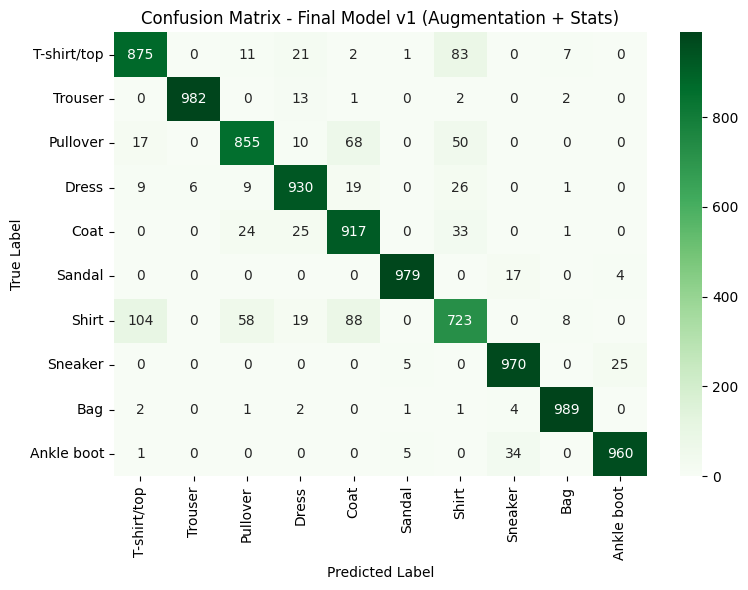

In [24]:
# Retrieve predictions and labels for confusion matrix visualization
final_model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in final_eval_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Confusion Matrix
final_mat = confusion_matrix(all_labels, all_predictions)

# Visualise Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(final_mat, annot=True, fmt='d', cmap='Greens',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Final Model v1 (Augmentation + Stats)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 7.1.3 Erweiterte Performance-Metriken Final Model v1
Um die Modellleistung über die reine Genauigkeit (Accuracy) hinaus zu bewerten, betrachten wir den detaillierten Klassifikationsbericht. Dies ist besonders nützlich, um zu sehen, welche Kleidungsstücke (z.B. 'Shirt' vs. 'T-shirt') das Modell am häufigsten verwechselt.

In [25]:
from sklearn.metrics import classification_report

# Erstellung des Berichts für das aktuellste Modell (v1)
report = classification_report(all_labels, all_predictions,
                               target_names=list(fashion_classes.values()))

print("Detaillierter Klassifikationsbericht (Final Model v1):\n")
print(report)

Detaillierter Klassifikationsbericht (Final Model v1):

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.89      0.85      0.87      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.84      0.92      0.88      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.79      0.72      0.75      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## 7.2 Final Model v2 with Learn Rate Optimizer and 60 epochs ##

In [26]:
# 1. Fresh instance of the model and optimizer
final_model_v2 = ImprovedFMNISTNet().to(device)
optimizer = optim.Adam(final_model_v2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss().to(device)

# 2. Setup Learning Rate Scheduler (monitoring validation loss)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
num_epochs_v2 = 60

# [SUGGESTION]: Split augmented training data into train (50k) and validation (10k) subsets
# to prevent data leakage (previously used the test set for LR scheduler)
# AND keep normalization stats consistent (mean/std normalized) to avoid devastating drop in accuracy.
from torch.utils.data import random_split
train_subset_v2, val_subset_v2 = random_split(augmented_train_data, [50000, 10000])

train_loader_v2 = torch.utils.data.DataLoader(
    train_subset_v2,
    batch_size=mini_batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=True
)

val_loader_v2 = torch.utils.data.DataLoader(
    val_subset_v2,
    batch_size=mini_batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True
)

train_losses_v2, val_losses_v2 = train_model(
    model=final_model_v2,
    train_loader=train_loader_v2,
    val_loader=val_loader_v2,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs_v2,
    models_directory=models_directory,
    model_name_prefix='fmnist_final_v2',
    scheduler=scheduler,
    device=device
)

# 3. Final Evaluation on UNSEEN Eval/Test data
final_model_v2.eval()
correct_v2 = 0
total_v2 = 0

# Note: We use the already-defined final_eval_dataloader, which uses final_eval_data
# (normalized unseen test set matching the training distribution).
with torch.no_grad():
    for images, labels in final_eval_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model_v2(images)
        preds = torch.argmax(outputs.data, 1)
        total_v2 += labels.size(0)
        correct_v2 += (preds == labels).sum().item()

acc_final_v2 = correct_v2 / total_v2
print(f'\n[RESULT] Final Model (60 Epochs + LR Scheduler) Test Accuracy: {acc_final_v2 * 100:.2f}%')


[LOG] Starting training for 60 epochs...
[LOG 2026-06-27 15:59:27] Epoch 01/60 | Train Loss: 0.5683 | Val Loss: 0.3790 | LR: 0.001000
[LOG 2026-06-27 16:01:02] Epoch 05/60 | Train Loss: 0.3330 | Val Loss: 0.2880 | LR: 0.001000
[LOG 2026-06-27 16:03:00] Epoch 10/60 | Train Loss: 0.2894 | Val Loss: 0.2602 | LR: 0.001000
[LOG 2026-06-27 16:04:59] Epoch 15/60 | Train Loss: 0.2677 | Val Loss: 0.2428 | LR: 0.001000
[LOG 2026-06-27 16:06:56] Epoch 20/60 | Train Loss: 0.2517 | Val Loss: 0.2296 | LR: 0.001000
[LOG 2026-06-27 16:08:56] Epoch 25/60 | Train Loss: 0.2394 | Val Loss: 0.2279 | LR: 0.001000
[LOG 2026-06-27 16:10:54] Epoch 30/60 | Train Loss: 0.2208 | Val Loss: 0.2169 | LR: 0.000500
[LOG 2026-06-27 16:12:49] Epoch 35/60 | Train Loss: 0.2063 | Val Loss: 0.2103 | LR: 0.000250
[LOG 2026-06-27 16:14:43] Epoch 40/60 | Train Loss: 0.1999 | Val Loss: 0.2038 | LR: 0.000125
[LOG 2026-06-27 16:16:38] Epoch 45/60 | Train Loss: 0.1972 | Val Loss: 0.2047 | LR: 0.000125
[LOG 2026-06-27 16:18:32] Epo

### 3.2.3 Visualization of Final Model v2

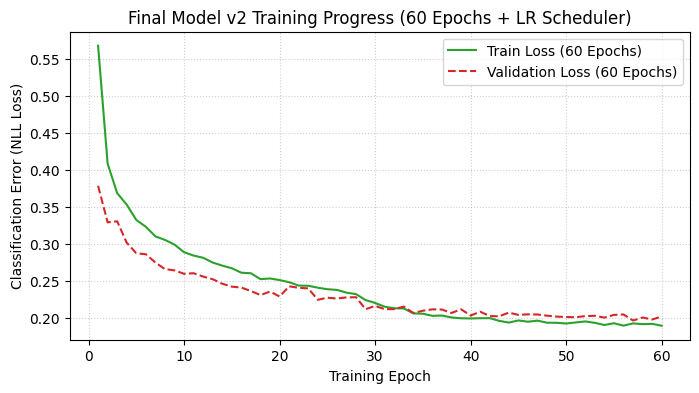

In [27]:
# =====================================================================
# 3.2.3 Visualization of Final Model v2 (Train vs. Validation Loss)
# =====================================================================
plt.figure(figsize=(8, 4))

# Kontinuierlicher Trainingsverlust
plt.plot(range(1, len(train_losses_v2) + 1), train_losses_v2,
         label='Train Loss (60 Epochs)', color='#2ca02c')

# Gestrichelte Validierungskurve zur optischen Differenzierung
plt.plot(range(1, len(val_losses_v2) + 1), val_losses_v2,
         label='Validation Loss (60 Epochs)', color='#d62728', linestyle='--')

plt.grid(True, linestyle='dotted', alpha=0.6)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Classification Error (NLL Loss)", fontsize=10)
plt.title("Final Model v2 Training Progress (60 Epochs + LR Scheduler)", fontsize=12)
plt.legend()
plt.show()

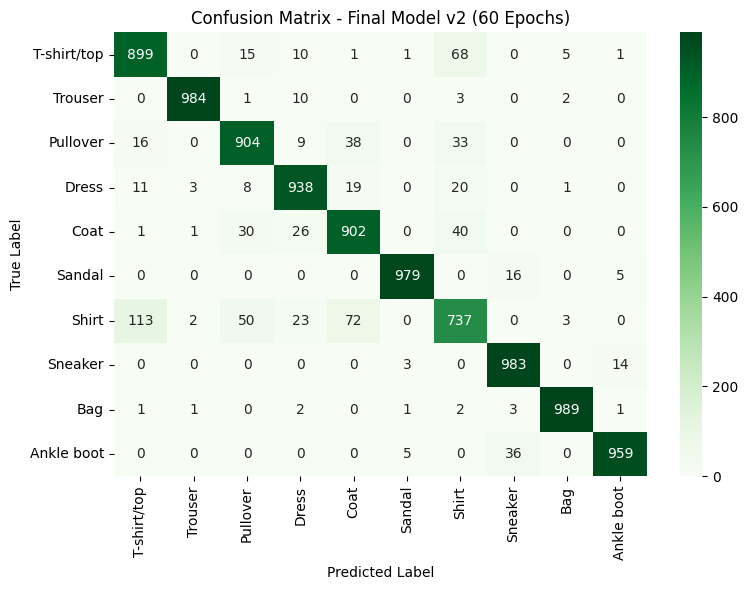

In [28]:
# Retrieve predictions for final_model_v2
final_model_v2.eval()
all_preds_v2 = []
all_labels_v2 = []

with torch.no_grad():
    for images, labels in final_eval_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model_v2(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds_v2.extend(preds.cpu().numpy())
        all_labels_v2.extend(labels.cpu().numpy())

# Calculate and plot Confusion Matrix
mat_v2 = confusion_matrix(all_labels_v2, all_preds_v2)
plt.figure(figsize=(8, 6))
sns.heatmap(mat_v2, annot=True, fmt='d', cmap='Greens',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Final Model v2 (60 Epochs)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 7.2.3 Erweiterte Performance-Metriken Final Model v2
Um die Modellleistung über die reine Genauigkeit (Accuracy) hinaus zu bewerten, betrachten wir den detaillierten Klassifikationsbericht. Dies ist besonders nützlich, um zu sehen, welche Kleidungsstücke (z.B. 'Shirt' vs. 'T-shirt') das Modell am häufigsten verwechselt.

In [29]:
from sklearn.metrics import classification_report

# Erstellung des Berichts für das aktuellste Modell (v2)
report = classification_report(all_labels_v2, all_preds_v2,
                               target_names=list(fashion_classes.values()))

print("Detaillierter Klassifikationsbericht (Final Model v2):\n")
print(report)

Detaillierter Klassifikationsbericht (Final Model v2):

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.90      0.88      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.90      0.90      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.87      0.90      0.89      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.82      0.74      0.77      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



## 8. Summary Performance Comparison
We now compare the test accuracy of all three model variants in a clear diagram.

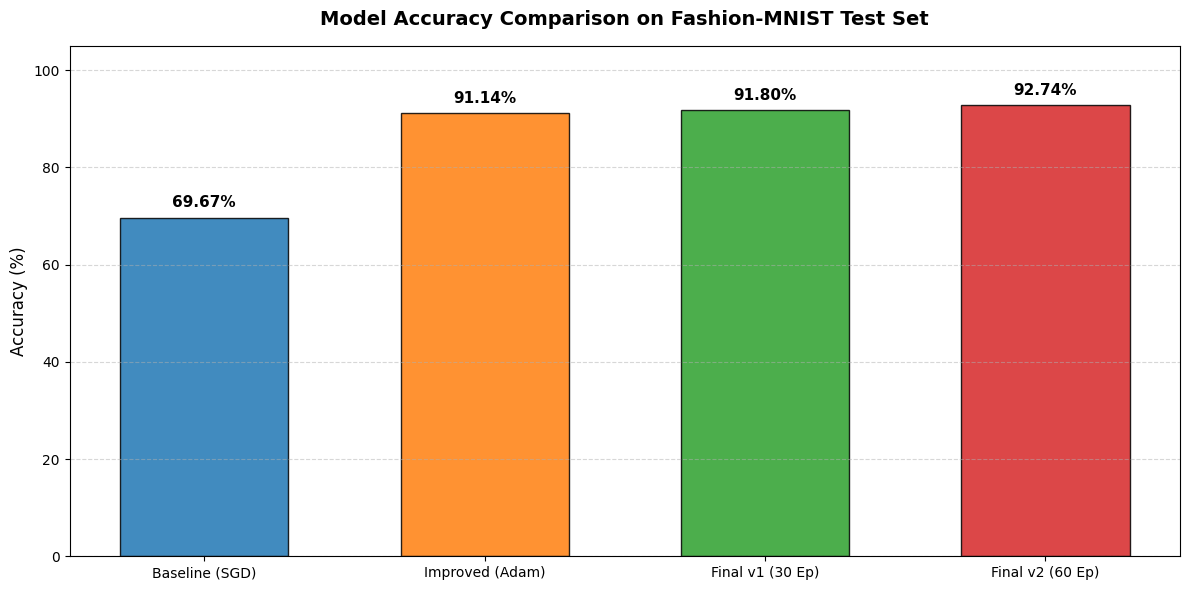

,Model Variant,Optimizer,Epochs,Augmentation,Normalization,Final Train Loss,Test Accuracy
0,Baseline CNN,SGD,30,None,ToTensor,0.8023,69.67%
1,Improved CNN,Adam,30,None,ToTensor,0.1258,91.14%
2,Final CNN (v1),Adam,30,Yes,Exact Stats,0.2220,91.80%
3,Final CNN (v2),Adam + Scheduler,60,Yes,Exact Stats,0.1901,92.74%


In [31]:
import pandas as pd

# 1. Bar chart comparing final test accuracies including v2
model_names = ['Baseline (SGD)', 'Improved (Adam)', 'Final v1 (30 Ep)', 'Final v2 (60 Ep)']
# Ensure all values are in the same scale (0-100)
accuracies = [acc_baseline * 100, acc_improved * 100, acc_final * 100, acc_final_v2 * 100]

plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', alpha=0.85, width=0.6)

plt.title('Model Accuracy Comparison on Fashion-MNIST Test Set', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Label exact values above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# 2. Comprehensive comparative summary table including v2
summary_data = {
    'Model Variant': ['Baseline CNN', 'Improved CNN', 'Final CNN (v1)', 'Final CNN (v2)'],
    'Optimizer': ['SGD', 'Adam', 'Adam', 'Adam + Scheduler'],
    'Epochs': [30, 30, 30, 60],
    'Augmentation': ['None', 'None', 'Yes', 'Yes'],
    'Normalization': ['ToTensor', 'ToTensor', 'Exact Stats', 'Exact Stats'],
    'Final Train Loss': [f"{train_epoch_losses[-1]:.4f}", f"{train_losses_improved[-1]:.4f}", f"{train_losses_final[-1]:.4f}", f"{train_losses_v2[-1]:.4f}"],
    'Test Accuracy': [f"{acc_baseline * 100:.2f}%", f"{acc_improved * 100:.2f}%", f"{acc_final * 100:.2f}%", f"{acc_final_v2 * 100:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)


### 8.1 Final Summary & Key Insights (PowerPoint Slide Deck Content) ###

This section summarizes the key findings of the project, formatted specifically as bullet points for your PowerPoint presentation slides.

---

#### Slide 1: Executive Summary & Project Objectives
*   **Core Goal:** Evaluate image classification performance on the Fashion-MNIST dataset by transitioning from vanilla Artificial Neural Networks (ANNs) to advanced Convolutional Neural Networks (CNNs).
*   **The Dataset:** Fashion-MNIST (Zalando's articles) consisting of 60,000 training and 10,000 testing 28x28 grayscale images across 10 clothing classes.
*   **Unbiased Evaluation Protocol:** Split the original 60k training set into **50,000 training images** (for weight updates) and **10,000 validation images** (for learning rate tuning). The 10,000 evaluation images were kept strictly unseen as the final test set to ensure zero data leakage.

#### Slide 2: Model Architecture & Complexity Evolution
*   **Baseline CNN (FMNISTNet):**
    *   LeNet-5 derivative with 2 convolutional layers (6 and 16 filters of size 5x5), 2 max-pooling layers, and 3 fully-connected layers.
    *   **Complexity:** 44,426 trainable parameters.
*   **Improved CNN (ImprovedFMNISTNet):**
    *   Expanded convolutional filter depth (16 and 32 filters of size 3x3), batch normalization, dropout (0.25) to mitigate overfitting, and 2 fully-connected layers.
    *   **Complexity:** 207,018 trainable parameters (**+365.98% parameter increase**).

#### Slide 3: Performance Comparison & Quantitative Results
*   **Summary of Experimental Results (Latest Run):**
    | Model Variant | Optimizer | Epochs | Augmentation | Normalization | Train Loss | Test Accuracy |
    | :--- | :--- | :---: | :---: | :---: | :---: | :---: |
    | **Baseline CNN** | SGD | 30 | None | ToTensor | 0.8023 | **69.67%** |
    | **Improved CNN** | Adam | 30 | None | ToTensor | 0.1258 | **91.14%** |
    | **Final CNN (v1)** | Adam | 30 | Yes | Exact Stats | 0.2220 | **91.80%** |
    | **Final CNN (v2)** | Adam + Scheduler | 60 | Yes | Exact Stats | 0.1901 | **92.74%** |
*   **Key Trend:** A clear and steady progression in generalization capability from the baseline to the final optimized pipeline, gaining **over 23 percentage points** in accuracy compared to the initial baseline.

#### Slide 4: Optimization & Regularization Key Insights
*   **Adam vs. SGD Convergence:** Baseline SGD (accuracy 69.67%) converges slowly. Switching to the Adam optimizer (accuracy 91.14%) handles the high-dimensional parameter space much more efficiently through adaptive learning rates.
*   **The Cost of Data Augmentation:** Introducing random rotations and horizontal flips makes learning initially more challenging but improves robustness. v1 achieved 91.80% within 30 epochs.
*   **Learning Rate Scheduling & Epoch Extension:** Extending training to 60 epochs and adding a `ReduceLROnPlateau` scheduler (Final v2) allowed the model to fine-tune weights on plateaus, achieving the peak accuracy of **92.74%**.
*   **Exact Stats Normalization:** Using specific Fashion-MNIST mean (0.2860) and standard deviation (0.3530) stabilized gradients and improved training stability.

#### Slide 5: Class-Specific Error Analysis (Confusion Matrix)
*   **High-Performing Classes:** The model achieved near-perfect classification for garments with unique spatial silhouettes:
    *   *Trouser* (Recall: 98%), *Bag* (Recall: 99%), *Sandal* (Recall: 98%), *Sneaker* (Recall: 98%).
*   **The Classification Bottleneck (Hardest Class):**
    *   *Shirt* (Recall: 74% - lowest by far).
    *   The model frequently confuses *Shirts* with *T-shirt/top*, *Pullover*, or *Coat* due to highly similar visual features (collars, sleeves).

#### Slide 6: Best Practices in Machine Learning & Refactoring
*   **Methodological Rigor:** Splitting off a dedicated validation set ensured that the test set remained completely unseen, providing an honest measure of true generalization.
*   **Clean Code & DRY Principles:** Consolidated duplicate training loops into a single reusable global `train_model` function, reducing redundancy and the risk of bugs.